# Module 6 — Comparison (real data vs model)

Reproduces the two comparison figures of the main text:

1. `fig_3.pdf` — 2×2 panel: `t(tau)`, `D(tau)`, `D_w(tau)` in natural time
   (top row) and `D(t)`, `D_w(t)` in intrinsic time (bottom row), data against
   model, for patents and papers;
2. `fig_4.pdf` — probability distributions of novelty frequencies, data
   against simulation.

Reduced real-data series and reduced model outputs are both read from
`outputs/`: run Module 1 and Module 5 first.


## Imports and base paths

Paths are resolved from the repository root by the bootstrap cell.

In [1]:
# Repository bootstrap.
# The notebooks are meant to be run from the repository root; the walk keeps
# them working when a front-end starts the kernel in a subdirectory.
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "lib").is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT / "lib") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "lib"))

OUTPUT_DIR = REPO_ROOT / "outputs"     # derived data, auto-generated
FIGURE_DIR = REPO_ROOT / "figures"     # manuscript figures, versioned
SIM_RUNS_DIR = REPO_ROOT / "sim_runs"  # model runs (N0 scan and selected run)

# Imports and base paths
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

from plot_style import apply_paper_style, DIST_COLORS, PAPER_COLORS

apply_paper_style(grid=False)
colors = list(PAPER_COLORS)
colors_dist = dict(DIST_COLORS)

base_dir = OUTPUT_DIR
# Per-year augmented patent CSVs, written by module_1_patents.
data_aug_dir = base_dir / "data_augmented_patents"


## Load patents data + model outputs

We load real data and the **reduced model outputs** generated by Module 5 (log/lin CSVs + frequency table).


In [2]:
# Patents data + model outputs
# --- Model parameters (must match Module 5 outputs) ---
T_patents = 41
nu_patents = 1.0
rho_patents = 1.0
N0_patents = 100500
# Explorer parameters used in the model
# num_estr = a * (w0 + w), and w increases by b
# (patents-like values)
a_patents = 0.0545
b_patents = 1.33
w0_patents = 269781

# --- Real data (reduced series) ---
pat_log = pd.read_csv(base_dir / "reduced_patents_log.csv")
pat_lin = pd.read_csv(base_dir / "reduced_patents_lin.csv")

years_log_pat = pat_log['years'].values
t_log_pat = pat_log['all_rows'].values
D_log_pat = pat_log['all_ipc'].values
w_log_pat = pat_log['all_first_authors'].values

years_lin_pat = pat_lin['years'].values
t_lin_pat = pat_lin['all_rows'].values
D_lin_pat = pat_lin['all_ipc'].values
w_lin_pat = pat_lin['all_first_authors'].values

# Frequency tables (data) from data_augmented_patents folder
freq_path = data_aug_dir / "ipc_combos_freq.csv"
df_ipc = pd.read_csv(freq_path)

ipc_freq_sorted = df_ipc['frequency'].sort_values(ascending=False).reset_index(drop=True)

# --- Model outputs (reduced log/lin + frequency) ---
model_prefix_pat = (
    f"model_T={T_patents}"
    f"_nu={nu_patents:.6g}_rho={rho_patents:.6g}"
    f"_N0={N0_patents}_a={a_patents:.6g}_b={b_patents:.6g}_w0={w0_patents:.6g}"
)

model_pat_log = pd.read_csv(base_dir / f"{model_prefix_pat}_log.csv")
model_pat_lin = pd.read_csv(base_dir / f"{model_prefix_pat}_lin.csv")
model_pat_freq = pd.read_csv(base_dir / f"{model_prefix_pat}_freq.csv")

# Simulation series (log + lin)
tau_log_pat_sim = model_pat_log['tau'].values
t_log_pat_sim = model_pat_log['t'].values
D_log_pat_sim = model_pat_log['D'].values
w_log_pat_sim = model_pat_log['w'].values

tau_lin_pat_sim = model_pat_lin['tau'].values
t_lin_pat_sim = model_pat_lin['t'].values
D_lin_pat_sim = model_pat_lin['D'].values
w_lin_pat_sim = model_pat_lin['w'].values

# Frequency (sim)
freq_D_sim_pat = model_pat_freq['frequency'].values


## Load papers data + model outputs

We load real data and the **reduced model outputs** generated by Module 5 (log/lin CSVs + frequency table).


In [3]:
# Papers data + model outputs
# --- Model parameters (must match Module 5 outputs) ---
T_papers = 41
nu_papers = 1.0
rho_papers = 1.0
N0_papers = 49000
# Explorer parameters used in the model
# num_estr = a * (w0 + w), and w increases by b
# (papers-like values)
a_papers = 0.167
b_papers = 0.71
w0_papers = 212313

# --- Real data (reduced series) ---
pap_log = pd.read_csv(base_dir / "reduced_openalex_log.csv")
pap_lin = pd.read_csv(base_dir / "reduced_openalex_lin.csv")

years_log_pap = pap_log['years'].values
t_log_pap = pap_log['row_indices'].values
D_log_pap = pap_log['num_unique_combinations'].values
w_log_pap = pap_log['num_unique_authors'].values

years_lin_pap = pap_lin['years'].values
t_lin_pap = pap_lin['row_indices'].values
D_lin_pap = pap_lin['num_unique_combinations'].values
w_lin_pap = pap_lin['num_unique_authors'].values

# Frequency tables (data)
combo_freq = pd.read_csv(base_dir / "openalex_combo_freq.csv")
combo_freqs = combo_freq['frequency'].values

# --- Model outputs (reduced log/lin + frequency) ---
model_prefix_pap = (
    f"model_T={T_papers}"
    f"_nu={nu_papers:.6g}_rho={rho_papers:.6g}"
    f"_N0={N0_papers}_a={a_papers:.6g}_b={b_papers:.6g}_w0={w0_papers:.6g}"
)

model_pap_log = pd.read_csv(base_dir / f"{model_prefix_pap}_log.csv")
model_pap_lin = pd.read_csv(base_dir / f"{model_prefix_pap}_lin.csv")
model_pap_freq = pd.read_csv(base_dir / f"{model_prefix_pap}_freq.csv")

# Simulation series (log + lin)
tau_log_pap_sim = model_pap_log['tau'].values
t_log_pap_sim = model_pap_log['t'].values
D_log_pap_sim = model_pap_log['D'].values
w_log_pap_sim = model_pap_log['w'].values

tau_lin_pap_sim = model_pap_lin['tau'].values
t_lin_pap_sim = model_pap_lin['t'].values
D_lin_pap_sim = model_pap_lin['D'].values
w_lin_pap_sim = model_pap_lin['w'].values

# Frequency (sim)
freq_D_sim_pap = model_pap_freq['frequency'].values


## Helper functions for the 2×2 panel

We create consistent plotting utilities for intrinsic time (τ) and real time (t).


In [4]:
# Panel helpers for the 2x2 comparison figure.
# Colour convention: navy -> D, firebrick -> t, amber -> D_w.
col_D, col_t, col_w = colors

labels_top = ['(a) patents EPO', '(b) papers OA']
labels_bot = ['(c) patents EPO', '(d) papers OA']


def last_per_unique_year(years, values):
    years = np.array(years)
    values = np.array(values)
    unique_years = np.unique(years)
    last_values = []
    for y in unique_years:
        mask = years == y
        last_values.append(values[mask][-1])
    return unique_years, np.array(last_values)


def lin_sample(x, y, n=30):
    x = np.array(x)
    y = np.array(y)
    mask = x > 0
    x, y = x[mask], y[mask]
    x_sample = np.linspace(x.min(), x.max(), n)
    y_sample = np.interp(x_sample, x, y)
    return x_sample, y_sample


def plot_tau(ax, years_data, t_data, D_data, w_data,
             tau_sim, t_sim, D_sim, w_sim,
             label):
    mask = (years_data - years_data[0]) % 2 == 0
    years_s = years_data[mask]
    t_s = t_data[mask]
    D_s = D_data[mask]
    w_s = w_data[mask]

    ax.plot(years_s, t_s, 'o', markersize=7.5, color=col_t)
    ax.plot(tau_sim + 1980, t_sim, '-', lw=2.5, color=col_t)

    ax.plot(years_s, D_s, 's', markersize=7.5, color=col_D)
    ax.plot(tau_sim + 1980, D_sim, '-', lw=2.5, color=col_D)

    ax.plot(years_s, w_s, '^', markersize=7.5, color=col_w)
    ax.plot(tau_sim + 1980, w_sim, '-', lw=2.5, color=col_w)

    ax.set_yscale("log")
    ax.set_xlabel(r"$\tau$")

    ax.text(0.5, 1.15, f"{label}", transform=ax.transAxes,
            fontsize=26, fontweight="bold", va="top", ha="center")

    if label == labels_top[0]:
        ax.text(0.08, 0.78, "intrinsic time", transform=ax.transAxes, color=col_t,
                fontsize=21, fontweight="bold")
        ax.text(0.18, 0.33, "novelties", transform=ax.transAxes, color=col_D,
                fontsize=21, fontweight="bold")
        ax.text(0.62, 0.59, "explorers", transform=ax.transAxes, color=col_w,
                fontsize=21, fontweight="bold")
    else:
        ax.text(0.08, 0.76, "intrinsic time", transform=ax.transAxes, color=col_t,
                fontsize=21, fontweight="bold")
        ax.text(0.18, 0.24, "novelties", transform=ax.transAxes, color=col_D,
                fontsize=21, fontweight="bold")
        ax.text(0.62, 0.5, "explorers", transform=ax.transAxes, color=col_w,
                fontsize=21, fontweight="bold")

    ax.text(-0.22, 0.26, r"$t(\tau)$,", transform=ax.transAxes, rotation=90,
            va="center", ha="left", color=col_t)
    ax.text(-0.22, 0.55, r"$D(\tau)$,", transform=ax.transAxes, rotation=90,
            va="center", ha="left", color=col_D)
    ax.text(-0.22, 0.88, r"$D_w(\tau)$", transform=ax.transAxes, rotation=90,
            va="center", ha="left", color=col_w)


def plot_t(ax, t_data, D_data, Dw_data,
           t_sim, D_sim, Dw_sim,
           label):
    ax.plot(t_data, D_data, 's', markersize=7, color=col_D)
    ax.plot(t_sim, D_sim, '-', lw=2.5, color=col_D)

    ax.plot(t_data, Dw_data, '^', markersize=7, color=col_w)
    ax.plot(t_sim, Dw_sim, '-', lw=2.5, color=col_w)

    ax.ticklabel_format(axis="both", style="sci", scilimits=(0, 0), useMathText=True)
    ax.set_xlabel(r"$t$")

    ax.text(0.5, 1.15, f"{label}", transform=ax.transAxes,
            fontsize=26, fontweight="bold", va="top", ha="center")

    if label == labels_bot[0]:
        ax.text(0.68, 0.4, "novelties", transform=ax.transAxes, color=col_D,
                fontsize=21, fontweight="bold")
        ax.text(0.52, 0.80, "explorers", transform=ax.transAxes, color=col_w,
                fontsize=21, fontweight="bold")

        ax.text(-0.20, 0.36, r"$D(t)$,", transform=ax.transAxes, rotation=90,
                va="center", ha="left", color=col_D)
        ax.text(-0.20, 0.69, r"$D_w(t)$", transform=ax.transAxes, rotation=90,
                va="center", ha="left", color=col_w)
    else:
        ax.set_yticks([0, 0.5 * 1e6, 1 * 1e6, 1.5 * 1e6])

        ax.text(0.54, 0.85, "novelties", transform=ax.transAxes, color=col_D,
                fontsize=21, fontweight="bold")
        ax.text(0.62, 0.35, "explorers", transform=ax.transAxes, color=col_w,
                fontsize=21, fontweight="bold")

        ax.text(-0.22, 0.36, r"$D(t)$,", transform=ax.transAxes, rotation=90,
                va="center", ha="left", color=col_D)
        ax.text(-0.22, 0.69, r"$D_w(t)$", transform=ax.transAxes, rotation=90,
                va="center", ha="left", color=col_w)


## Plot 2×2 comparison (data vs model)

Top row: intrinsic time τ. Bottom row: real time t.


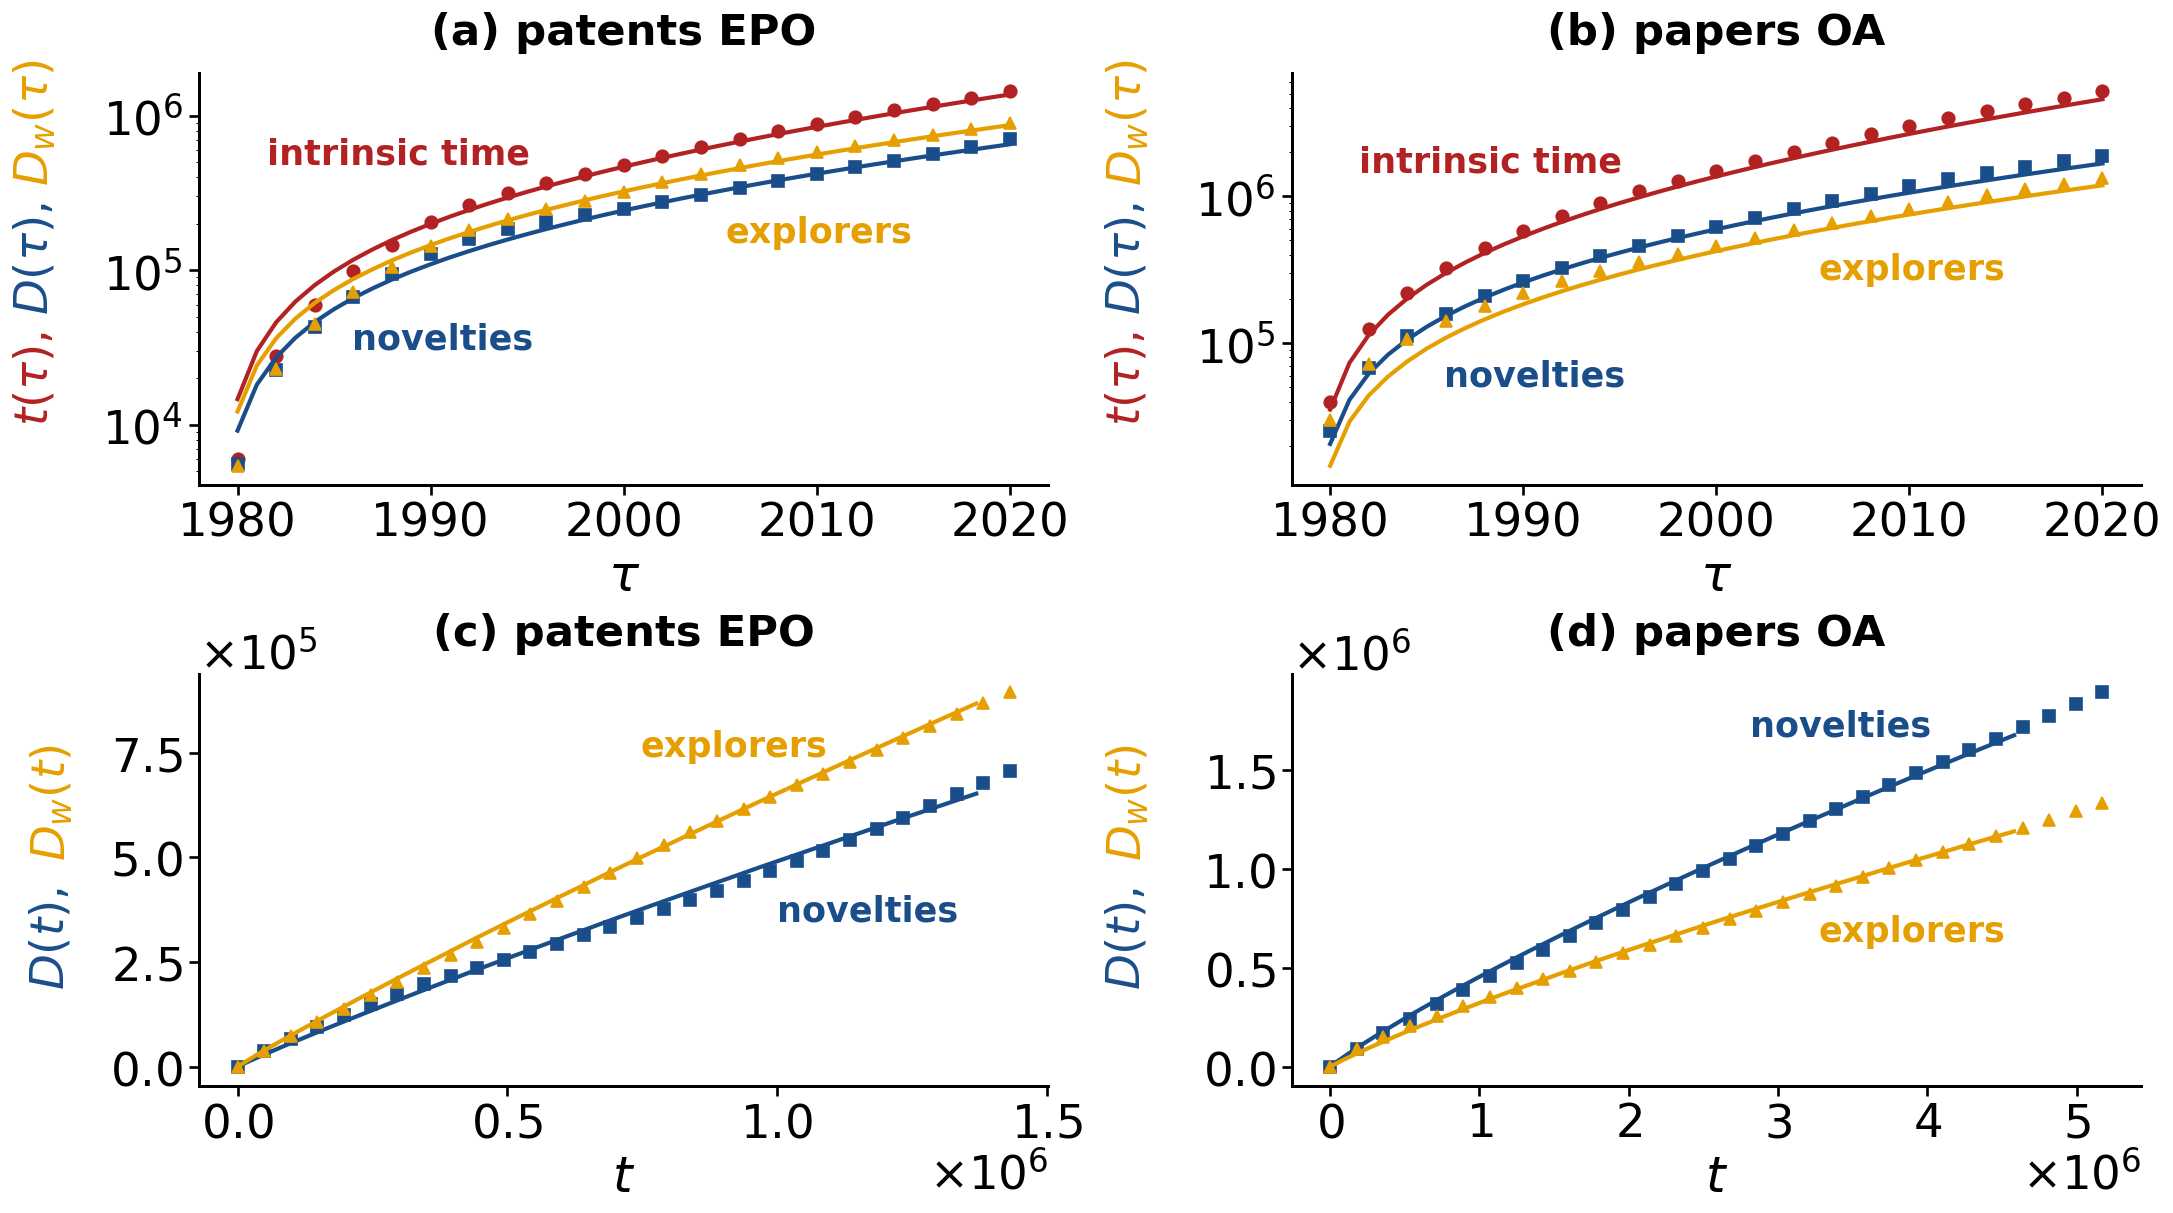

In [5]:
# --- patents: one simulated point per distinct tau, and the last data
# point of each year ---
tau_to_t = {tau: t for tau, t in zip(tau_lin_pat_sim, t_lin_pat_sim)}
tau_pat, t_sim_pat = zip(*tau_to_t.items())

tau_to_D = {tau: D for tau, D in zip(tau_lin_pat_sim, D_lin_pat_sim)}
_, D_sim_pat = zip(*tau_to_D.items())

tau_to_w = {tau: w for tau, w in zip(tau_lin_pat_sim, w_lin_pat_sim)}
_, w_sim_pat = zip(*tau_to_w.items())

tau_pat = np.array(tau_pat)
t_sim_pat = np.array(t_sim_pat)
D_sim_pat = np.array(D_sim_pat)
w_sim_pat = np.array(w_sim_pat)

years_pat, t_pat = last_per_unique_year(years_lin_pat, t_lin_pat)
_, D_pat = last_per_unique_year(years_lin_pat, D_lin_pat)
_, w_pat = last_per_unique_year(years_lin_pat, w_lin_pat)

# --- papers: same reduction ---
tau_to_t = {tau: t for tau, t in zip(tau_lin_pap_sim, t_lin_pap_sim)}
tau_pap, t_sim_pap = zip(*tau_to_t.items())

tau_to_D = {tau: D for tau, D in zip(tau_lin_pap_sim, D_lin_pap_sim)}
_, D_sim_pap = zip(*tau_to_D.items())

tau_to_w = {tau: w for tau, w in zip(tau_lin_pap_sim, w_lin_pap_sim)}
_, w_sim_pap = zip(*tau_to_w.items())

tau_pap = np.array(tau_pap)
t_sim_pap = np.array(t_sim_pap)
D_sim_pap = np.array(D_sim_pap)
w_sim_pap = np.array(w_sim_pap)

years_pap, t_pap = last_per_unique_year(years_lin_pap, t_lin_pap)
_, D_pap = last_per_unique_year(years_lin_pap, D_lin_pap)
_, w_pap = last_per_unique_year(years_lin_pap, w_lin_pap)

all_rows_log_pat_s, all_ipc_log_pat_s = lin_sample(t_log_pat, D_log_pat)
all_rows_log_pat_w_s, all_first_authors_log_pat_s = lin_sample(t_log_pat, w_log_pat)

all_rows_log_pap_s, combos_log_pap_s = lin_sample(t_log_pap, D_log_pap)
all_rows_log_pap_w_s, all_first_authors_log_pap_s = lin_sample(t_log_pap, w_log_pap)

fig, axs = plt.subplots(2, 2, figsize=(18, 10), constrained_layout=True)

# --- top row: natural time tau ---
plot_tau(axs[0, 0],
         years_pat, t_pat, D_pat, w_pat,
         tau_pat, t_sim_pat, D_sim_pat, w_sim_pat,
         labels_top[0])

plot_tau(axs[0, 1],
         years_pap, t_pap, D_pap, w_pap,
         tau_pap, t_sim_pap, D_sim_pap, w_sim_pap,
         labels_top[1])

# --- bottom row: intrinsic time t ---
plot_t(axs[1, 0],
       all_rows_log_pat_s,
       all_ipc_log_pat_s,
       all_first_authors_log_pat_s,
       t_log_pat_sim,
       D_log_pat_sim + 1,
       w_log_pat_sim + 1,
       labels_bot[0])

plot_t(axs[1, 1],
       all_rows_log_pap_s,
       combos_log_pap_s + 1,
       all_first_authors_log_pap_s,
       t_log_pap_sim,
       D_log_pap_sim + 1,
       w_log_pap_sim + 1,
       labels_bot[1])

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURE_DIR / "fig_3.pdf", bbox_inches="tight")
plt.show()

## Plot probability distributions (data vs model)

We compare the novelty frequency distributions for patents and papers.


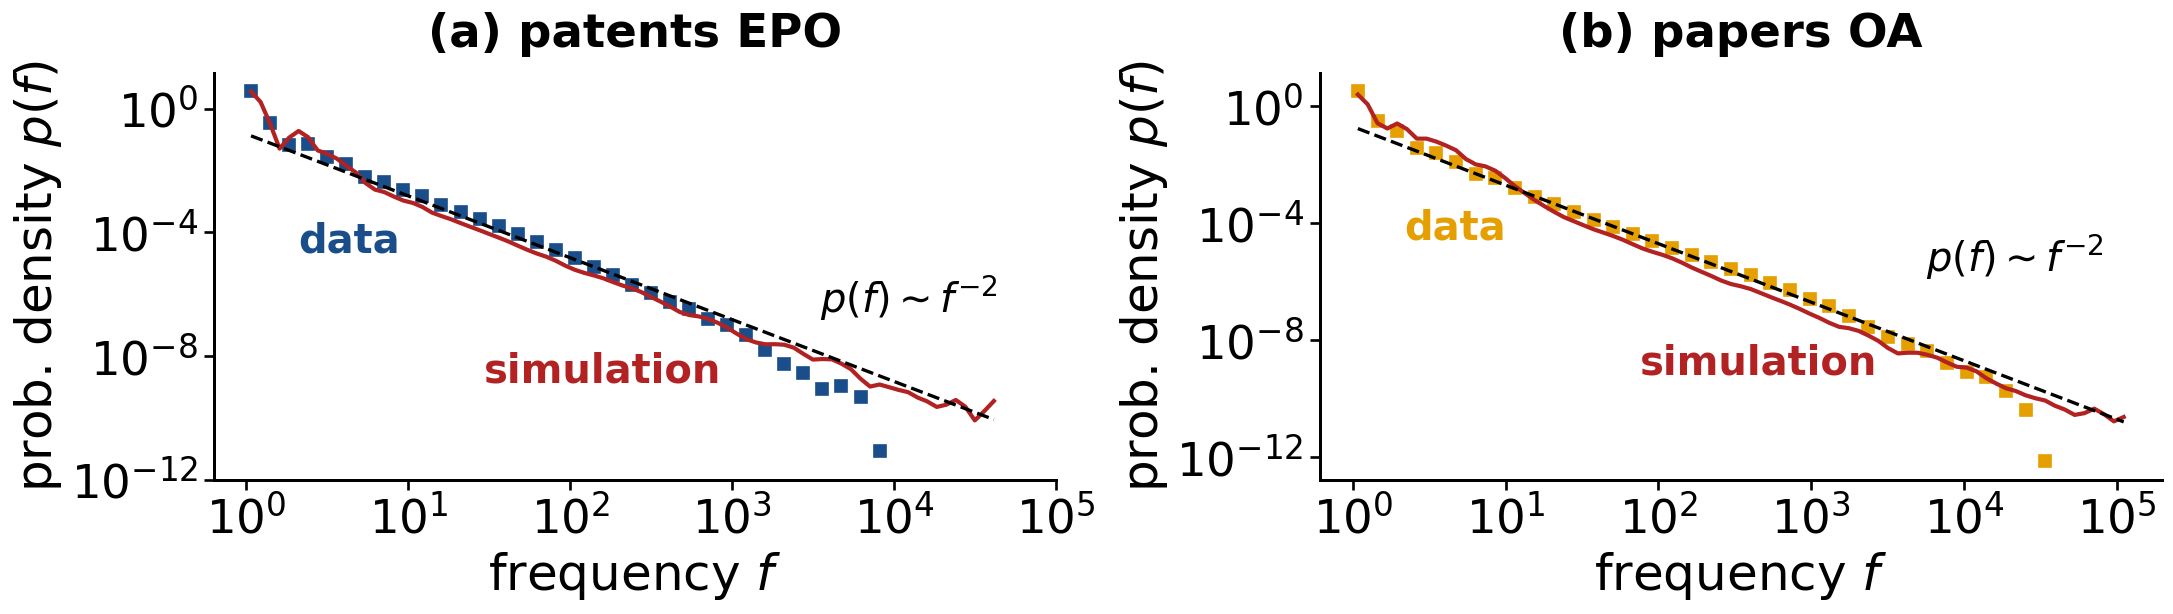

In [6]:
# Plot probability distributions (data vs model)
colors_dist = {
    "patents": "#1A4E8A",
    "sim": "#B22222",
    "papers": "#E69F00",
}

fig, axs = plt.subplots(1, 2, figsize=(18, 5), constrained_layout=True)
labels = ['(a) patents EPO', '(b) papers OA']

# --- (a) PATENTS ---
freq_data = np.array(ipc_freq_sorted)
freq_sim = np.array(freq_D_sim_pat)

freq_data = freq_data[freq_data > 0]
freq_sim = freq_sim[freq_sim > 0]

bins = np.logspace(np.log10(min(freq_data.min(), freq_sim.min())),
                   np.log10(max(freq_data.max(), freq_sim.max())), 80)

bin_centers = np.sqrt(bins[:-1] * bins[1:])

hist_data, _ = np.histogram(freq_data, bins=bins, density=True)
hist_sim, _ = np.histogram(freq_sim, bins=bins, density=True)

hist_data_smooth = gaussian_filter1d(hist_data, sigma=1)
hist_sim_smooth = gaussian_filter1d(hist_sim, sigma=1)

ax = axs[0]
ax.loglog(bin_centers[hist_data_smooth > 0][::2], hist_data_smooth[hist_data_smooth > 0][::2],
          's', markersize=7, lw=3, color=colors_dist["patents"])
ax.loglog(bin_centers[hist_sim_smooth > 0], hist_sim_smooth[hist_sim_smooth > 0],
          '-', lw=2.5, color=colors_dist["sim"])
ax.loglog(bin_centers, 0.15 * bin_centers**(-2.), '--', lw=2, color='black')

ax.set_xlabel(r"frequency $f$")
ax.set_ylabel(r"prob. density $p(f)$")
ax.text(0.5, 1.15, labels[0], transform=ax.transAxes,
        fontsize=28, fontweight='bold', ha='center', va='top')
ax.text(0.10, 0.56, "data", transform=ax.transAxes,
        color=colors_dist["patents"], fontsize=24, fontweight='bold')
ax.text(0.32, 0.24, "simulation", transform=ax.transAxes,
        color=colors_dist["sim"], fontsize=24, fontweight='bold')
ax.text(0.72, 0.41, r"$p(f)\sim f^{-2}$", transform=ax.transAxes,
        color='black', fontsize=24, fontweight='bold')

ax.set_xticks([10**0, 10**1, 10**2, 10**3, 10**4, 10**5])
ax.set_yticks([10**(-12), 10**(-8), 10**(-4), 10**0])

# --- (b) PAPERS ---
freq_data = np.sort(np.array(combo_freqs))
freq_sim = np.array(freq_D_sim_pap)

freq_data = freq_data[freq_data > 0]
freq_sim = freq_sim[freq_sim > 0]

bins = np.logspace(np.log10(min(freq_data.min(), freq_sim.min())),
                   np.log10(max(freq_data.max(), freq_sim.max())), 80)

bin_centers = np.sqrt(bins[:-1] * bins[1:])

hist_data, _ = np.histogram(freq_data, bins=bins, density=True)
hist_sim, _ = np.histogram(freq_sim, bins=bins, density=True)

hist_data_smooth = gaussian_filter1d(hist_data, sigma=1)
hist_sim_smooth = gaussian_filter1d(hist_sim, sigma=1)

ax = axs[1]
ax.loglog(bin_centers[hist_data_smooth > 0][::2], hist_data_smooth[hist_data_smooth > 0][::2],
          's', markersize=7, lw=3, color=colors_dist["papers"])
ax.loglog(bin_centers[hist_sim_smooth > 0], hist_sim_smooth[hist_sim_smooth > 0],
          '-', lw=2.5, color=colors_dist["sim"])
ax.loglog(bin_centers, 0.2 * bin_centers**(-2.), '--', lw=2, color='black')

ax.set_xlabel(r"frequency $f$")
ax.set_ylabel(r"prob. density $p(f)$")
ax.text(0.5, 1.15, labels[1], transform=ax.transAxes,
        fontsize=28, fontweight='bold', ha='center', va='top')
ax.text(0.10, 0.59, "data", transform=ax.transAxes,
        color=colors_dist["papers"], fontsize=24, fontweight='bold')
ax.text(0.38, 0.26, "simulation", transform=ax.transAxes,
        color=colors_dist["sim"], fontsize=24, fontweight='bold')
ax.text(0.72, 0.51, r"$p(f)\sim f^{-2}$", transform=ax.transAxes,
        color='black', fontsize=24, fontweight='bold')

ax.set_xticks([10**0, 10**1, 10**2, 10**3, 10**4, 10**5])
ax.set_yticks([10**(-12), 10**(-8), 10**(-4), 10**0])

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURE_DIR / "fig_4.pdf", bbox_inches="tight")
plt.show()